In [22]:
import numpy as np

import pandas as pd

import tubesml as tml

from source.report import report_victory, yearly_wrapper, _point_to_proba
from source.validate import random_split, yearly_split

from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, brier_score_loss
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge, LogisticRegression, Lasso
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb

In [23]:
train_dict = {}
test_dict = {}

for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:
    df = pd.read_csv(f"data/results/men_train_{model}.csv")
    df = df.rename(columns={"oof_prob": f"{model}_pred"})
    df = df[["Season", "ID", "target", f"{model}_pred"] + [c for c in df if "stage" in c]]
    df[[c for c in df if "stage" in c]] = df[[c for c in df if "stage" in c]].astype(int)
    train_dict[model] = df
    df = pd.read_csv(f"data/results/men_test_{model}.csv")
    df = df.rename(columns={"pred_prob": f"{model}_pred"})
    df = df[["Season", "ID", "target", f"{model}_pred"] + [c for c in df if "stage" in c]]
    df[[c for c in df if "stage" in c]] = df[[c for c in df if "stage" in c]].astype(int)
    test_dict[model] = df

In [24]:
train_dict["lasso"].head()

,Season,ID,target,lasso_pred,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible
0,2022,2022_1308_1163,1,0.157453,1,0,0,0,0,0,0
1,2018,2018_1355_1326,0,0.286385,1,0,0,0,0,0,0
2,2013,2013_1266_1139,1,0.565265,0,1,0,0,0,0,0
3,2011,2011_1361_1396,1,0.674542,0,1,0,0,0,0,0
4,2013,2013_1196_1322,1,0.935003,1,0,0,0,0,0,0


In [25]:
df_train = train_dict["lasso"].copy()
df_test = test_dict["lasso"].copy()

for model in ["lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:

    df_train = pd.merge(df_train, train_dict[model][["ID", f"{model}_pred"]], how="left", on="ID")
    df_test = pd.merge(df_test, test_dict[model][["ID", f"{model}_pred"]], how="left", on="ID")

df_train["mean_pred"] = df_train[['ridge_pred', 'logit_pred', 'lasso_pred', 'lgb_pred', 'xgb_pred']].mean(axis=1)  # from below test
df_test["mean_pred"] = df_test[['ridge_pred', 'logit_pred', 'lasso_pred', 'lgb_pred', 'xgb_pred']].mean(axis=1)

In [26]:
df_train.head()

,Season,ID,target,lasso_pred,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,lgb_class_pred,lgb_pred,logit_pred,ridge_pred,xgb_class_pred,xgb_pred,mean_pred
0,2022,2022_1308_1163,1,0.157453,1,0,0,0,0,0,0,0.280556,0.264561,0.185579,0.162332,0.301199,0.275725,0.209130
1,2018,2018_1355_1326,0,0.286385,1,0,0,0,0,0,0,0.251808,0.221051,0.293888,0.367639,0.246617,0.252722,0.284337
2,2013,2013_1266_1139,1,0.565265,0,1,0,0,0,0,0,0.558915,0.483102,0.590342,0.520882,0.751426,0.565733,0.545065
3,2011,2011_1361_1396,1,0.674542,0,1,0,0,0,0,0,0.708677,0.646830,0.809081,0.714591,0.793789,0.690511,0.707111
4,2013,2013_1196_1322,1,0.935003,1,0,0,0,0,0,0,0.766005,0.863375,0.965080,0.979228,0.772762,0.894651,0.927467


In [27]:
df_test.head()

,Season,ID,target,lasso_pred,stage_Round1,stage_Round2,stage_Round3,stage_Round4,stage_final,stage_finalfour,stage_impossible,lgb_class_pred,lgb_pred,logit_pred,ridge_pred,xgb_class_pred,xgb_pred,mean_pred
0,2025,2025_1196_1222,1,0.457211,0,0,0,0,1,0,0,0.519444,0.500750,0.398592,0.503469,0.570578,0.546591,0.481323
1,2024,2024_1112_1173,1,0.726294,0,1,0,0,0,0,0,0.736535,0.718728,0.693615,0.743604,0.621538,0.687237,0.713896
2,2021,2021_1333_1397,1,0.260445,1,0,0,0,0,0,0,0.290902,0.417517,0.246902,0.328927,0.428135,0.383661,0.327490
3,2023,2023_1397_1181,1,0.439181,0,1,0,0,0,0,0,0.513669,0.427252,0.421302,0.390110,0.336680,0.477088,0.430987
4,2009,2009_1295_1242,0,0.198971,1,0,0,0,0,0,0,0.248136,0.131498,0.210442,0.201791,0.154843,0.158214,0.180183


array([[<Axes: title={'center': 'lasso_pred'}>,
        <Axes: title={'center': 'lgb_class_pred'}>,
        <Axes: title={'center': 'lgb_pred'}>],
       [<Axes: title={'center': 'logit_pred'}>,
        <Axes: title={'center': 'ridge_pred'}>,
        <Axes: title={'center': 'xgb_class_pred'}>],
       [<Axes: title={'center': 'xgb_pred'}>,
        <Axes: title={'center': 'mean_pred'}>, <Axes: >]], dtype=object)

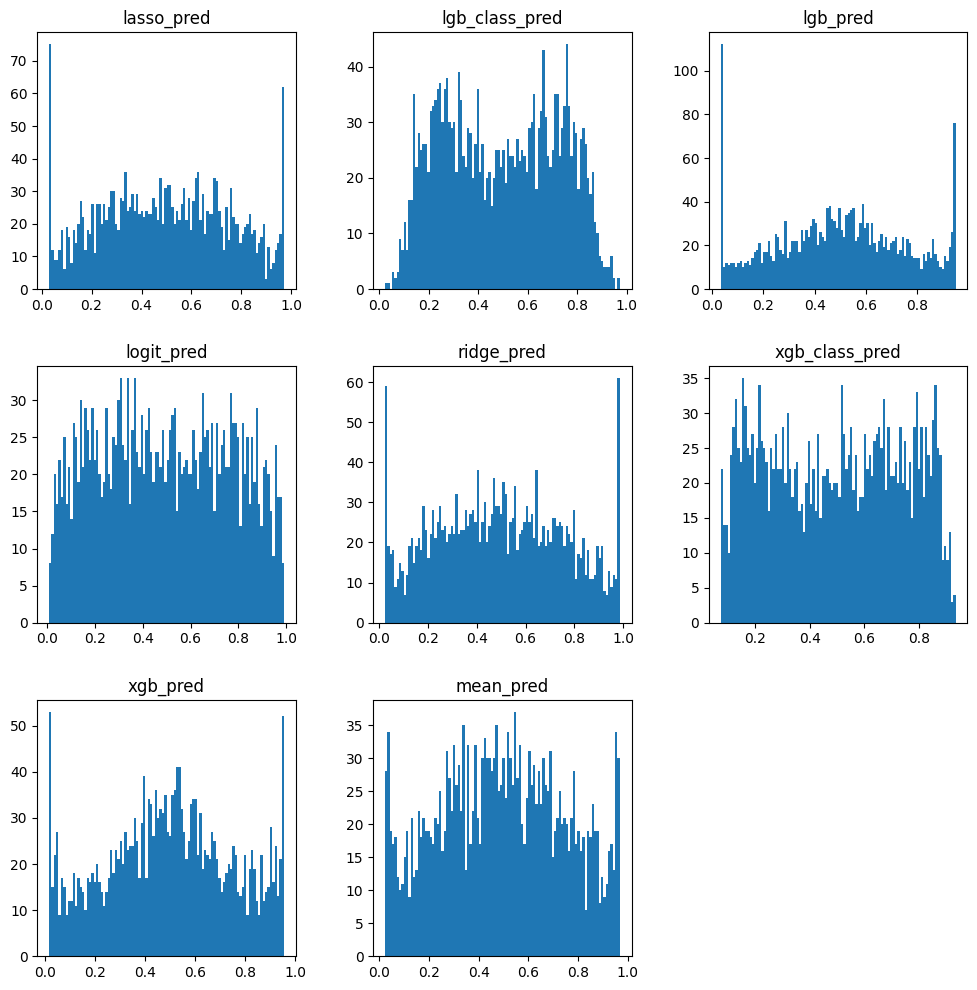

In [28]:
df_train[[c for c in df_train if "pred" in c]].hist(bins=100, grid=False, figsize=(12,12))

array([[<Axes: title={'center': 'lasso_pred'}>,
        <Axes: title={'center': 'lgb_class_pred'}>,
        <Axes: title={'center': 'lgb_pred'}>],
       [<Axes: title={'center': 'logit_pred'}>,
        <Axes: title={'center': 'ridge_pred'}>,
        <Axes: title={'center': 'xgb_class_pred'}>],
       [<Axes: title={'center': 'xgb_pred'}>,
        <Axes: title={'center': 'mean_pred'}>, <Axes: >]], dtype=object)

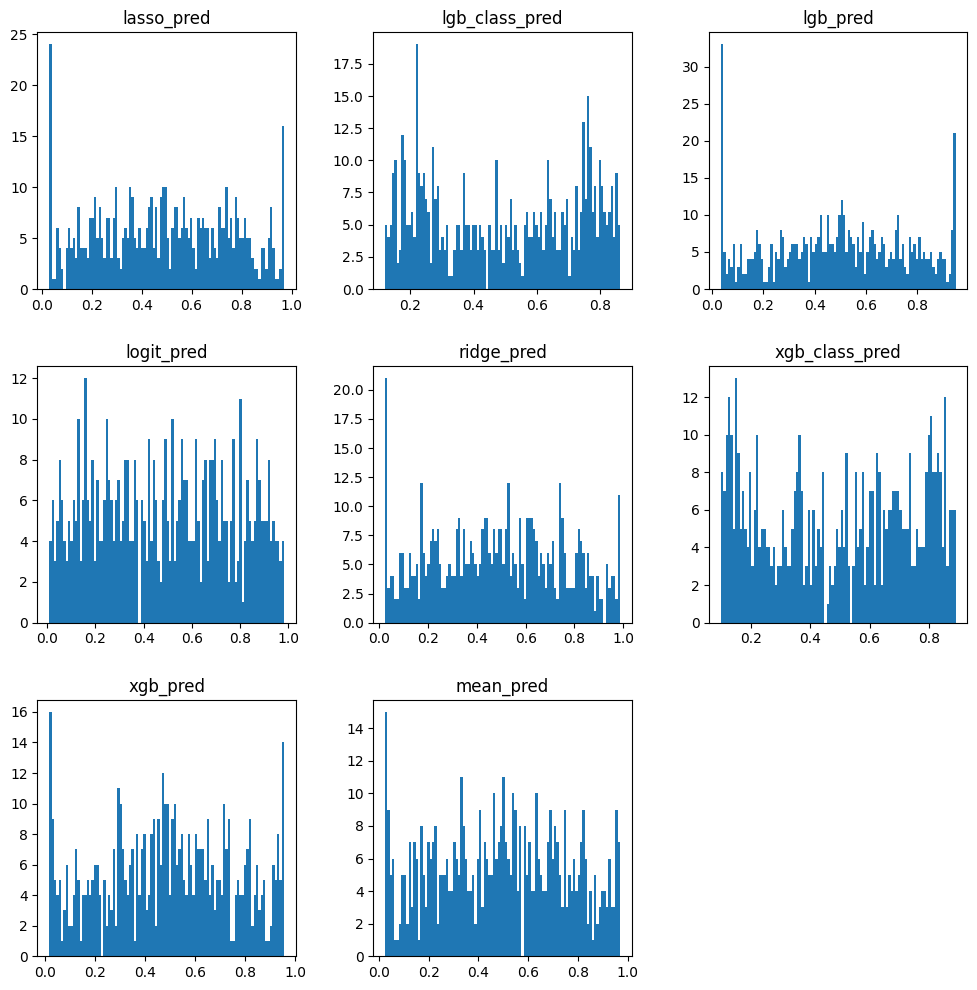

In [29]:
df_test[[c for c in df_test if "pred" in c]].hist(bins=100, grid=False, figsize=(12,12))

In [30]:
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    print(model)
    print(f"Accuracy train: {accuracy_score(y_true=df_train["target"], y_pred=df_train[f'{model}_pred'] > 0.5)}")
    print(f"Accuracy test: {accuracy_score(y_true=df_test["target"], y_pred=df_test[f'{model}_pred'] > 0.5)}")
    print(f"Brier train: {brier_score_loss(y_true=df_train["target"], y_prob=df_train[f'{model}_pred'])}")
    print(f"Brier test: {brier_score_loss(y_true=df_test["target"], y_prob=df_test[f'{model}_pred'])}")

lasso
Accuracy train: 0.7182718271827183
Accuracy test: 0.7140287769784173
Brier train: 0.18396436480232392
Brier test: 0.18251632901493048
lgb_class
Accuracy train: 0.7115211521152115
Accuracy test: 0.6960431654676259
Brier train: 0.18855573120782013
Brier test: 0.18781370291780383
lgb
Accuracy train: 0.7065706570657065
Accuracy test: 0.7050359712230215
Brier train: 0.185253236214105
Brier test: 0.1821951054519698
logit
Accuracy train: 0.7268226822682268
Accuracy test: 0.7212230215827338
Brier train: 0.18338011181590314
Brier test: 0.18063826335985164
ridge
Accuracy train: 0.7173717371737174
Accuracy test: 0.7068345323741008
Brier train: 0.1822393438443217
Brier test: 0.18415073460414527
xgb_class
Accuracy train: 0.7061206120612061
Accuracy test: 0.6996402877697842
Brier train: 0.18860605960175564
Brier test: 0.19093412119291342
xgb
Accuracy train: 0.7097209720972097
Accuracy test: 0.7032374100719424
Brier train: 0.1859996456113014
Brier test: 0.18070170994569443
mean
Accuracy train: 

# Per stage

In [31]:
res_train = pd.DataFrame()
res_test = pd.DataFrame()

for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    model_acc_train = []
    model_brier_train = []
    model_acc_test = []
    model_brier_test = []

    for stage in ["Round1", "Round2", "Round3", "Round4", "finalfour", "final"]:
        tmp_train = df_train[df_train[f"stage_{stage}"] == 1]
        tmp_test = df_test[df_test[f"stage_{stage}"] == 1]
        model_acc_train.append(accuracy_score(y_true=tmp_train["target"], y_pred=tmp_train[f'{model}_pred'] > 0.5))
        model_acc_test.append(accuracy_score(y_true=tmp_test["target"], y_pred=tmp_test[f'{model}_pred'] > 0.5))

        model_brier_train.append(brier_score_loss(y_true=tmp_train["target"], y_prob=tmp_train[f'{model}_pred']))
        model_brier_test.append(brier_score_loss(y_true=tmp_test["target"], y_prob=tmp_test[f'{model}_pred']))

    res_train[f"{model}_accuracy"] = model_acc_train
    res_train[f"{model}_brier"] = model_brier_train
    res_test[f"{model}_accuracy"] = model_acc_test
    res_test[f"{model}_brier"] = model_brier_test

res_train.index = ["Round1", "Round2", "Round3", "Round4", "finalfour", "final"]
res_test.index = ["Round1", "Round2", "Round3", "Round4", "finalfour", "final"]

In [32]:
res_train[[c for c in res_train if "brier" in c]]

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,0.166185,0.173509,0.166770,0.164799,0.161982,0.173927,0.165729,0.162161
Round2,0.181459,0.183237,0.183733,0.182279,0.181981,0.182579,0.189390,0.180769
Round3,0.216777,0.218118,0.219157,0.210565,0.206855,0.213868,0.218762,0.211165
Round4,0.257475,0.257959,0.256366,0.265933,0.265577,0.262590,0.254233,0.256523
finalfour,0.204928,0.217092,0.206170,0.221766,0.225277,0.207870,0.202035,0.208965
final,0.189460,0.187471,0.201067,0.173144,0.198515,0.208827,0.201585,0.189781


In [33]:
res_train[[c for c in res_train if "brier" in c]].rank(axis=1)

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,5.0,7.0,6.0,3.0,1.0,8.0,4.0,2.0
Round2,2.0,6.0,7.0,4.0,3.0,5.0,8.0,1.0
Round3,5.0,6.0,8.0,2.0,1.0,4.0,7.0,3.0
Round4,4.0,5.0,2.0,8.0,7.0,6.0,1.0,3.0
finalfour,2.0,6.0,3.0,7.0,8.0,4.0,1.0,5.0
final,3.0,2.0,6.0,1.0,5.0,8.0,7.0,4.0


In [34]:
res_train[[c for c in res_train if "brier" in c]].rank(axis=1).mean()

lasso_brier        3.500000
lgb_class_brier    5.333333
lgb_brier          5.333333
logit_brier        4.166667
ridge_brier        4.166667
xgb_class_brier    5.833333
xgb_brier          4.666667
mean_brier         3.000000
dtype: float64

In [35]:
res_test[[c for c in res_train if "brier" in c]]

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,0.164531,0.170546,0.164842,0.162885,0.162065,0.172983,0.161602,0.161461
Round2,0.208435,0.213804,0.211705,0.205049,0.210371,0.225923,0.211946,0.207261
Round3,0.169099,0.168887,0.162030,0.166893,0.173452,0.168976,0.163752,0.164759
Round4,0.221217,0.236802,0.217435,0.219308,0.243731,0.237295,0.216715,0.221649
finalfour,0.179378,0.188670,0.194563,0.175180,0.186586,0.176905,0.191830,0.183652
final,0.270685,0.254113,0.243648,0.302107,0.278999,0.196047,0.243058,0.264713


In [36]:
res_test[[c for c in res_train if "brier" in c]].rank(axis=1)

,lasso_brier,lgb_class_brier,lgb_brier,logit_brier,ridge_brier,xgb_class_brier,xgb_brier,mean_brier
Round1,5.0,7.0,6.0,4.0,3.0,8.0,2.0,1.0
Round2,3.0,7.0,5.0,1.0,4.0,8.0,6.0,2.0
Round3,7.0,5.0,1.0,4.0,8.0,6.0,2.0,3.0
Round4,4.0,6.0,2.0,3.0,8.0,7.0,1.0,5.0
finalfour,3.0,6.0,8.0,1.0,5.0,2.0,7.0,4.0
final,6.0,4.0,3.0,8.0,7.0,1.0,2.0,5.0


In [37]:
res_test[[c for c in res_train if "brier" in c]].rank(axis=1).mean()

lasso_brier        4.666667
lgb_class_brier    5.833333
lgb_brier          4.166667
logit_brier        3.500000
ridge_brier        5.833333
xgb_class_brier    5.333333
xgb_brier          3.333333
mean_brier         3.333333
dtype: float64

# Per prediction probability

In [38]:
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    bins = np.arange(0, 1.05, 0.05)  # 0, 0.05, 0.10, ..., 1.00

    labels = [f"{model}_{round(bins[i],2)}–{round(bins[i+1],2)}" for i in range(len(bins)-1)]

    df_train[f"{model}_bins"] = pd.cut(df_train[f"{model}_pred"], bins=bins, labels=labels, include_lowest=True)
    df_test[f"{model}_bins"] = pd.cut(df_test[f"{model}_pred"], bins=bins, labels=labels, include_lowest=True)

In [39]:
df_train.groupby("lgb_class_bins", observed=True)["target"].mean()

lgb_class_bins
lgb_class_0.0–0.05    0.000000
lgb_class_0.05–0.1    0.076923
lgb_class_0.1–0.15    0.065217
lgb_class_0.15–0.2    0.150376
lgb_class_0.2–0.25    0.183432
lgb_class_0.25–0.3    0.227273
lgb_class_0.3–0.35    0.422078
lgb_class_0.35–0.4    0.304348
lgb_class_0.4–0.45    0.418803
lgb_class_0.45–0.5    0.550459
lgb_class_0.5–0.55    0.535433
lgb_class_0.55–0.6    0.596899
lgb_class_0.6–0.65    0.551724
lgb_class_0.65–0.7    0.658228
lgb_class_0.7–0.75    0.745342
lgb_class_0.75–0.8    0.814371
lgb_class_0.8–0.85    0.881890
lgb_class_0.85–0.9    0.892308
lgb_class_0.9–0.95    0.958333
lgb_class_0.95–1.0    0.666667
Name: target, dtype: float64

In [40]:
df_train.groupby("mean_bins", observed=True)["target"].mean()

mean_bins
mean_0.0–0.05    0.025316
mean_0.05–0.1    0.041096
mean_0.1–0.15    0.076923
mean_0.15–0.2    0.174757
mean_0.2–0.25    0.247619
mean_0.25–0.3    0.275591
mean_0.3–0.35    0.295775
mean_0.35–0.4    0.384000
mean_0.4–0.45    0.393333
mean_0.45–0.5    0.479730
mean_0.5–0.55    0.529032
mean_0.55–0.6    0.569343
mean_0.6–0.65    0.673913
mean_0.65–0.7    0.680851
mean_0.7–0.75    0.700000
mean_0.75–0.8    0.809524
mean_0.8–0.85    0.804598
mean_0.85–0.9    0.896552
mean_0.9–0.95    0.957143
mean_0.95–1.0    0.951613
Name: target, dtype: float64

In [41]:
df_train[df_train["mean_pred"] > 0.7].groupby("logit_bins", observed=True)["target"].mean()

logit_bins
logit_0.55–0.6    0.000000
logit_0.65–0.7    0.800000
logit_0.7–0.75    0.681818
logit_0.75–0.8    0.721649
logit_0.8–0.85    0.820000
logit_0.85–0.9    0.866667
logit_0.9–0.95    0.977011
logit_0.95–1.0    0.925373
Name: target, dtype: float64

# Models

In [42]:
def train_predict(data, test_data, target, estimator, cv, test_target=None, fit_params=None, early_stopping=False, shap=True, result_compare=None):
    cv_score = tml.CrossValidate(data=data, target=target, test=test_data,
                                 estimator=estimator, cv=cv, fit_params=fit_params, early_stopping=early_stopping,
                                shap=shap, imp_coef=True, predict_proba=True, regression=False)

    oof, pred, result_dict = cv_score.score()

    score = brier_score_loss(y_true=target, y_prob=oof)
    print(f"OOF score: {score}")

    if early_stopping:
        print(result_dict["iterations"])

    if shap:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="both", n=10)
        to_plot = result_dict["feat_imp"].head(10)["Feature"].to_list()
        tml.plot_shap_values(result_dict["shap_values"], features=to_plot)
    else:
        tml.plot_feat_imp(result_dict["feat_imp"], imp="standard", n=10)

    tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    if result_compare is not None:
        baseline = result_compare["score"]
        ref_oof = result_compare["oof"]

        if score - baseline >= 0:
            print(f"This is {round((score - baseline) / baseline * 100, 3)}% worse than the baseline.")
        else:
            print(f"This is {round(-(score - baseline) / baseline * 100, 3)}% better than the baseline.")
    
        comparison = tml.CompareModels(data=data, true_label=target.reset_index(drop=True),
                                       pred_1=oof, pred_2=ref_oof,
                                       kfold=cv,
                                       regression=True,
                                       probabilities=True,
                                       metric_func=mean_squared_error)
    
        comparison.compare_metrics()
        comparison.compare_predictions()
        comparison.statistical_significance()

    if test_target is not None:
        score = brier_score_loss(y_true=test_target, y_prob=pred)
        print(f"Test score: {score}")
        tml.eval_classification(data=data, target=target, preds=oof,
                        proba=True, thrs=0.5, plot=True, feat="delta_Seed")

    return oof, pred, result_dict

In [43]:
DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"] + [c for c in df_train if "bins" in c or "mean" in c or "class" in c]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

In [44]:
def pred_per_stage(data):
    df = data.copy()
    for c in ["stage_Round1", "stage_Round2", "stage_Round3", "stage_Round3", "stage_finalfour", "stage_final"]:
        for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:
            df[f"{model}_{c}_keep"] = df[f"{model}_pred"] * df[c]

    return df[[c for c in df if "_keep" in c]]

OOF score: 0.19106894325941975
[20, 15, 17, 19, 14]


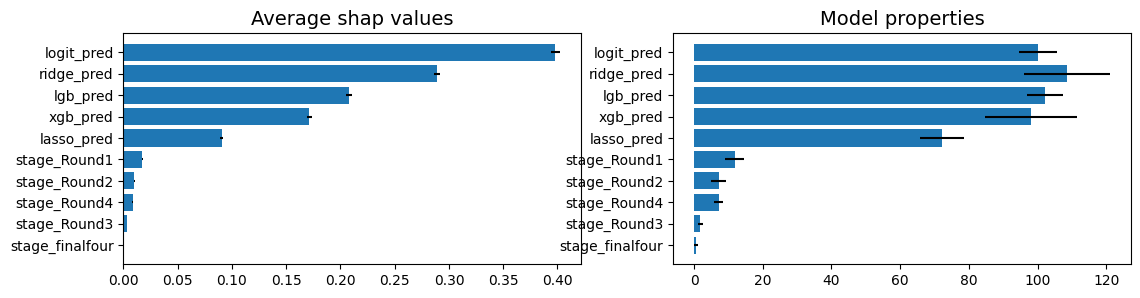

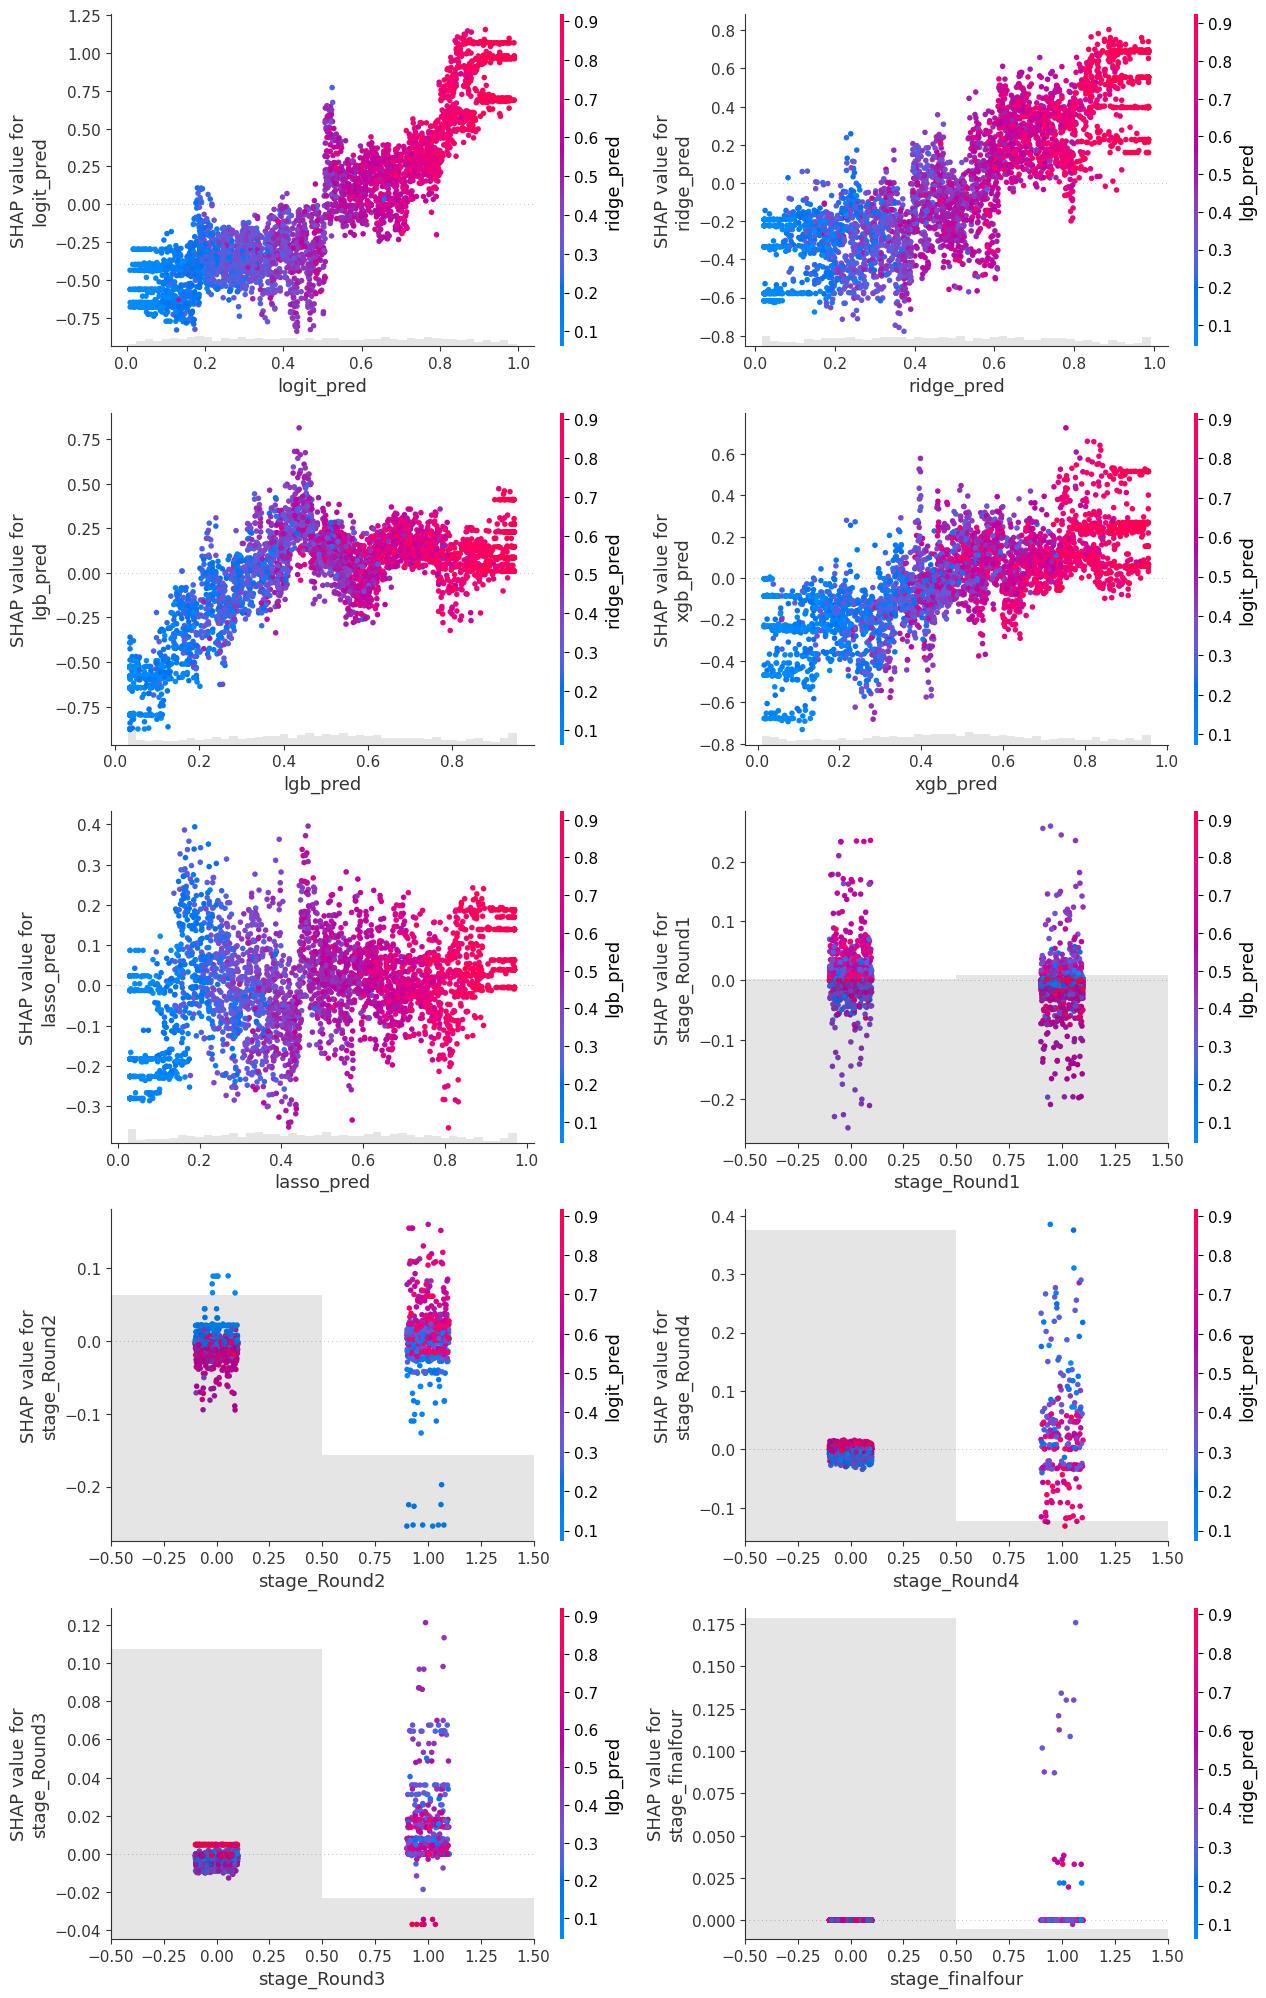

The feature delta_Seed is not in the provided data, it will be ignored


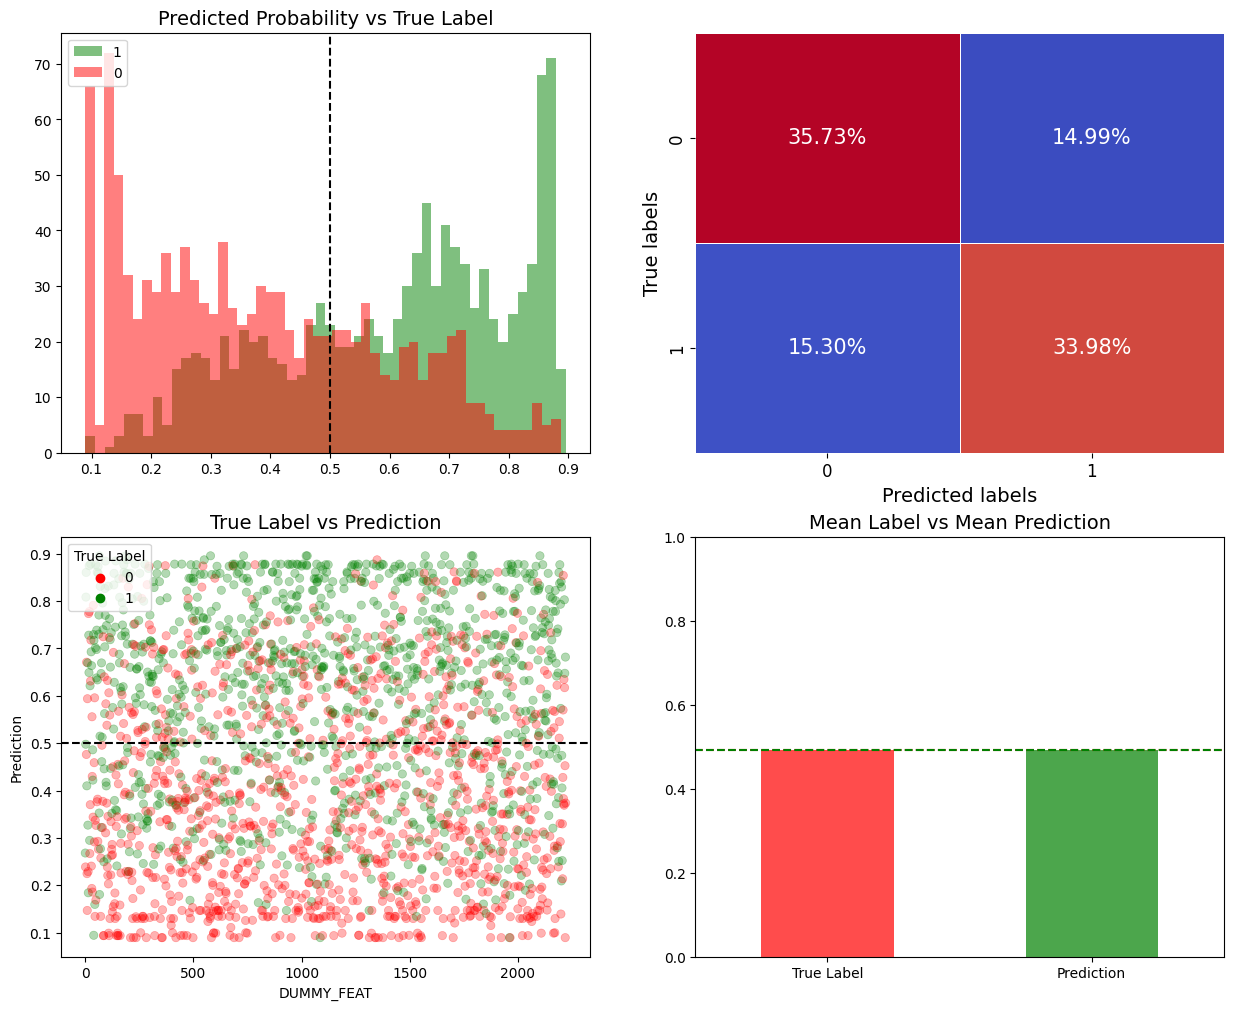

Accuracy score: 	0.6971
AUC ROC: 		0.7801
              precision    recall  f1-score   support

           0       0.70      0.70      0.70      1127
           1       0.69      0.69      0.69      1095

    accuracy                           0.70      2222
   macro avg       0.70      0.70      0.70      2222
weighted avg       0.70      0.70      0.70      2222

Test score: 0.1846525522029589


The feature delta_Seed is not in the provided data, it will be ignored


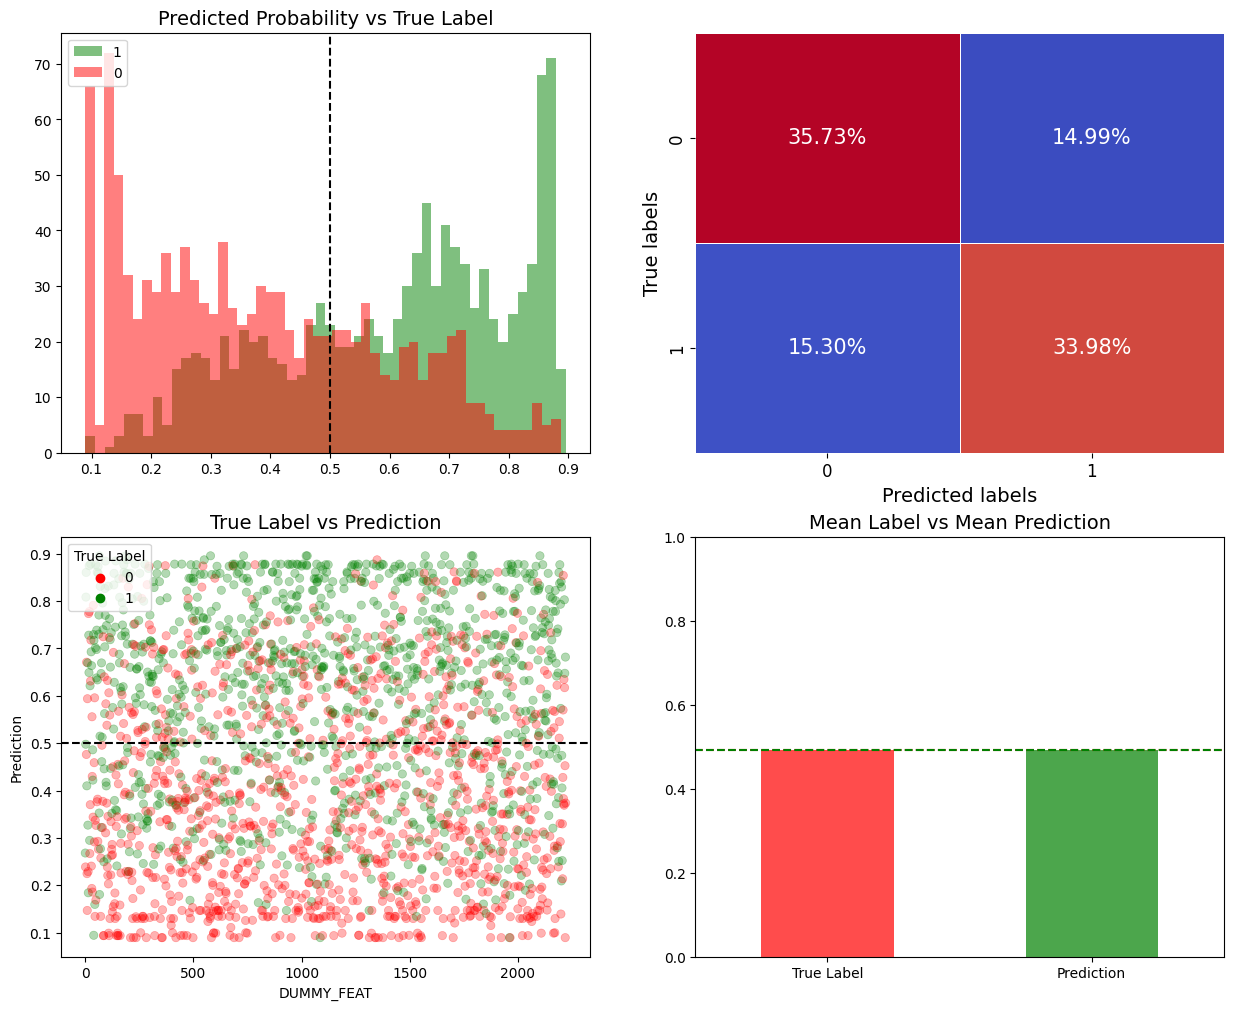

Accuracy score: 	0.6971
AUC ROC: 		0.7801
              precision    recall  f1-score   support

           0       0.70      0.70      0.70      1127
           1       0.69      0.69      0.69      1095

    accuracy                           0.70      2222
   macro avg       0.70      0.70      0.70      2222
weighted avg       0.70      0.70      0.70      2222

Accuracy train: 		 0.6971
Accuracy test: 			 0.7158
Logloss train: 			 0.5613
Logloss test: 			 0.5465
Brier train: 			 0.1911
Brier test: 			 0.1847
Unsure train: 			 23.0873%
Unsure test: 			 22.482%


,acc_oof,acc_test,logloss_oof,logloss_test,unsure_oof,unsure_test,brier_oof,brier_test
0,0.6971,0.7158,0.5613,0.5465,23.0873,22.482,0.1911,0.1847


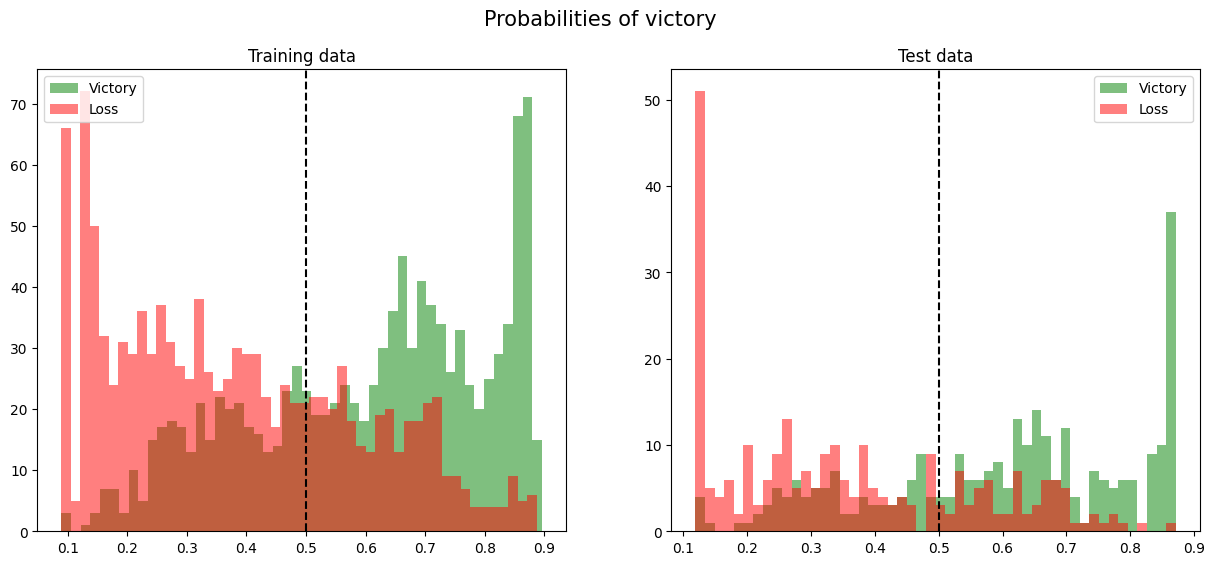

In [45]:
target = df_train["target"]


FEATURES = [c for c in df_train if c not in DROP]
train = df_train[FEATURES].copy()
test_target = df_test["target"]
test = df_test[FEATURES].copy()

# train = pred_per_stage(train)
# test = pred_per_stage(test)

model = lgb.LGBMClassifier(random_state=34, n_jobs=-1, verbose=-1, n_estimators=10000,
                               learning_rate=0.1,
                            #  colsample_bytree=0.817,
                            #  min_child_weight=5.62,
                            #  reg_lambda=14.72,
                            #  reg_alpha=2.16,
                            #  subsample=0.722,
                            #  num_leaves=66,
                            #  max_depth=95,
                             eval_metric="auc")

pipe = Pipeline([
                ("imp", tml.DfImputer()),
                ("model", model)])

callbacks = [lgb.early_stopping(1000, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "auc"}


oof, pred, result_dict = train_predict(data=train, test_data=test, target=target,
                                       estimator=pipe, cv=kfolds, test_target=test_target,
                                       fit_params=fit_params, early_stopping=True,
                                       shap=True, result_compare=None)


report_victory(y_train=target, y_test=test_target, oof=oof, preds=pred)

# How certain are they

In [46]:
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb"]:
    df_train[f"{model}_certain"] = np.where((df_train[f"{model}_pred"] > 0.8) | ((df_train[f"{model}_pred"] < 0.2)), 1, 0)
    df_test[f"{model}_certain"] = np.where((df_test[f"{model}_pred"] > 0.8) | ((df_test[f"{model}_pred"] < 0.2)), 1, 0)

In [47]:
df_train["tot_certain"] = df_train[[c for c in df_train if "certain" in c]].sum(axis=1)
df_test["tot_certain"] = df_test[[c for c in df_test if "certain" in c]].sum(axis=1)

In [48]:
df_test[["tot_certain"]].describe()

,tot_certain
count,556.00000
mean,2.21223
std,2.82682
min,0.00000
25%,0.00000
50%,0.00000
75%,5.00000
max,7.00000


In [49]:
tmp_train = df_train[df_train["tot_certain"] >= 4].copy()
tmp_test = df_test[df_test["tot_certain"] >= 4].copy()
for model in ["lasso", "lgb_class", "lgb", "logit", "ridge", "xgb_class", "xgb", "mean"]:
    print(model)
    print("Before")
    print(brier_score_loss(y_true=tmp_train["target"], y_prob=tmp_train[f'{model}_pred']))
    print(brier_score_loss(y_true=tmp_test["target"], y_prob=tmp_test[f'{model}_pred']))
    print("After")
    tmp_train.loc[tmp_train[f"{model}_pred"] > 0.5, f"{model}_pred"] = 0.99
    tmp_train.loc[tmp_train[f"{model}_pred"] < 0.5, f"{model}_pred"] = 0.01
    tmp_test.loc[tmp_test[f"{model}_pred"] > 0.5, f"{model}_pred"] = 0.99
    tmp_test.loc[tmp_test[f"{model}_pred"] < 0.5, f"{model}_pred"] = 0.01
    print(brier_score_loss(y_true=tmp_train["target"], y_prob=tmp_train[f'{model}_pred']))
    print(brier_score_loss(y_true=tmp_test["target"], y_prob=tmp_test[f'{model}_pred']))

lasso
Before
0.082064938531625
0.0919644436258194
After
0.09252276422764227
0.10773005780346821
lgb_class
Before
0.09512360422964691
0.10063232106177658
After
0.09252276422764227
0.10773005780346821
lgb
Before
0.08187231614985539
0.0955455069833998
After
0.09252276422764227
0.10773005780346821
logit
Before
0.08292745612531527
0.09324963614577629
After
0.09252276422764227
0.10773005780346821
ridge
Before
0.08275063481243888
0.0928160802160933
After
0.09252276422764227
0.10773005780346821
xgb_class
Before
0.09006925319579016
0.10041123242455634
After
0.09252276422764227
0.10773005780346821
xgb
Before
0.08292719127324495
0.0946028314700642
After
0.09252276422764227
0.10773005780346821
mean
Before
0.0812945361724195
0.0927690089474882
After
0.09252276422764227
0.10773005780346821


# Better mean

In [50]:
to_use = []

for model in ["ridge", "logit", "lasso", "lgb", "xgb", "lgb_class", "xgb_class"]:
    to_use.append(f"{model}_pred")
    df_train["mean_pred"] = df_train[to_use].mean(axis=1)
    df_test["mean_pred"] = df_test[to_use].mean(axis=1)
    print(to_use)
    print(brier_score_loss(y_true=df_train["target"], y_prob=df_train[f'mean_pred']))
    print(brier_score_loss(y_true=df_test["target"], y_prob=df_test[f'mean_pred']))

['ridge_pred']
0.1822393438443217
0.18415073460414527
['ridge_pred', 'logit_pred']
0.1815071488869118
0.18122457697369201
['ridge_pred', 'logit_pred', 'lasso_pred']
0.18160165795040817
0.18115942536961138
['ridge_pred', 'logit_pred', 'lasso_pred', 'lgb_pred']
0.18132186077363188
0.18050514478503518
['ridge_pred', 'logit_pred', 'lasso_pred', 'lgb_pred', 'xgb_pred']
0.18112184341787982
0.1800650616883253
['ridge_pred', 'logit_pred', 'lasso_pred', 'lgb_pred', 'xgb_pred', 'lgb_class_pred']
0.18138433126128048
0.18075247554711849
['ridge_pred', 'logit_pred', 'lasso_pred', 'lgb_pred', 'xgb_pred', 'lgb_class_pred', 'xgb_class_pred']
0.18156509201146254
0.18149636088954005


# Max per model

In [57]:
df_train["max_pred"] = df_train["mean_pred"]
df_train.loc[df_train["mean_pred"] > 0.9, "max_pred"] = df_train[[f"{model}_pred" for model in ["ridge", "logit", "lasso", "lgb", "xgb", "lgb_class", "xgb_class"]]].max(axis=1)
df_train.loc[df_train["mean_pred"] < 0.1, "max_pred"] = df_train[[f"{model}_pred" for model in ["ridge", "logit", "lasso", "lgb", "xgb", "lgb_class", "xgb_class"]]].min(axis=1)

brier_score_loss(y_true=df_train["target"], y_prob=df_train[f'max_pred'])

0.18140344080838472

# By year evaluation

In [3]:
class ClassifierModel():
    def __init__(self, pipeline, train_data, test_data, train_target, cv, fit_params=None, early_stopping=False):
        self.pipe = pipeline
        self.train_data = train_data
        self.test_data = test_data
        self.train_target = train_target
        self.cv = cv
        self.fit_params = fit_params
        self.early_stopping = early_stopping

    def fit(self, X=None, y=None):
        cv_score = tml.CrossValidate(data=self.train_data, target=self.train_target, test=self.test_data,
                                 estimator=self.pipe, cv=self.cv, fit_params=self.fit_params,
                                 predict_proba=True,
                                 early_stopping=self.early_stopping, regression=False)

        self.oof, self.pred, _ = cv_score.score()

        return self

    def predict(self, X=None, y=None):
        return self.pred

    
class RegressorModel():
    def __init__(self, pipeline, train_data, test_data, train_target, cv, cutoff, padding, fit_params=None, early_stopping=False):
        self.pipe = pipeline
        self.train_data = train_data
        self.test_data = test_data
        self.train_target = train_target
        self.cv = cv
        self.fit_params = fit_params
        self.early_stopping = early_stopping
        self.cutoff = cutoff
        self.padding = padding

    def fit(self, X=None, y=None):
        cv_score = tml.CrossValidate(data=self.train_data, target=self.train_target, test=self.test_data,
                                 estimator=self.pipe, cv=self.cv, fit_params=self.fit_params,
                                 early_stopping=self.early_stopping, regression=True)

        point_oof, point_pred, _ = cv_score.score()

        self.oof, self.pred = _point_to_proba(oof=point_oof, y_train=self.train_target,
                                    preds=point_pred, clip_val=self.cutoff, padd=self.padding)

        return self

    def predict(self, X=None):
        return self.pred

In [10]:
df = pd.read_csv("data/processed/men_training.csv")

In [20]:
DROP = ["target", "target_points", "ID", "DayNum", "Team1", "Team2",
        'T1_Loc', 'T2_Loc',
                "T1_region", "T2_region", "Season", "delta_Loc",
                "Season", "competitive", "competitive_score",
                "delta_def_rating_diff", "delta_impact_diff",
                "T1_def_rating_diff", "T2_def_rating_diff"] + [c for c in df if "bins" in c or "mean" in c or "class" in c]


N_FOLDS = 5
kfolds = KFold(n_splits=N_FOLDS, shuffle=True, random_state=13)

In [21]:
lasso_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Lasso(random_state=34, alpha=0.1, max_iter=10000))])

lasso_not_imp = [
 'delta_def_edge',
 'delta_OT_win',
 'delta_FGM',
 'delta_Ast_TO_ratio',
 'delta_OT_win_perc',
 'delta_FTA_diff',
 'delta_DR',
 'delta_opp_FTA',
 'delta_quality',
 'delta_Ast_diff',
 'delta_FTA',
 'delta_FTM',
 'delta_FTM_diff',
 'delta_DR_diff',
 'delta_Opp_eff_shooting_perc',
 'delta_Eff_shooting_perc',
 'delta_Ast',
 'delta_True_shooting_perc',
 'delta_TO',
 'delta_Stl',
 'delta_Score',
 'delta_PF_diff',
 'delta_OR',
 'delta_TO_diff',
 'delta_TO_perposs_diff',
 'delta_TO_perposs',
 'delta_off_rating_diff',
 'delta_opp_FGA',
 'delta_FGA3',
 'delta_opp_FGM',
 'delta_Tot_Reb_diff',
 'delta_True_shooting_perc_diff',
 'delta_def_rating',
 'delta_Tot_Reb',
 'delta_FGM3_diff',
 'delta_FGM3',
 'delta_FGA_diff',
 'delta_FGA3_diff',
 'delta_opp_score',
 'delta_possessions',
 'delta_opp_TO',
 'delta_opp_possessions',
 'delta_FG3_ratio',
 'delta_Eff_FG_perc_diff',
 'delta_FGA',
 'delta_FGA2',
 'delta_shtg_opportunity',
 'delta_FGA2_diff',
 'delta_FGM_no_ast_perc',
 'delta_FGM_perc']

lasso_feat = [c for c in df if "delta" in c and c not in DROP and c not in lasso_not_imp]

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    lasso = RegressorModel(pipeline=lasso_pipe,
                            train_data=train[lasso_feat],
                            test_data=test[lasso_feat],
                            train_target=train["target_points"],
                            cv=kfolds, cutoff=32, padding=0.02)

    lasso.fit()

    pred = lasso.predict()
    oof = lasso.oof

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))


2022
0.1810557408140718
0.22887993869504786
2023
0.18195513169875988
0.20649194284778097
2024
0.18309189178715943
0.1876563485644794
2025
0.1853967939466786
0.15121130582335313


In [18]:
ridge_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Ridge(random_state=34, alpha=0.1, max_iter=10000))])

ridge_feat = [c for c in df if "delta" in c and c not in DROP]

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    ridge = RegressorModel(pipeline=ridge_pipe,
                            train_data=train[ridge_feat],
                            test_data=test[ridge_feat],
                            train_target=train["target_points"],
                            cv=kfolds, cutoff=21, padding=0.01)

    ridge.fit()

    pred = ridge.predict()
    oof = ridge.oof

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))

2022
0.1803388576511634
0.21121256068395394
2023
0.18113227600211468
0.20687936735246676
2024
0.1822146147086978
0.19205393875797244
2025
0.18566529407770208
0.1748121388572699


In [19]:
model = lgb.LGBMRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                          learning_rate=0.01,
                         max_depth=115, num_leaves=97,
                         reg_lambda=98, reg_alpha=64,
                         colsample_bytree=0.335, subsample=0.81,
                         min_child_weight=79.7, eval_metric="l2", verbose=-1)

lgb_pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

callbacks = [lgb.early_stopping(100, verbose=0)]
    
fit_params = {"callbacks":callbacks, "eval_metric": "l2"}

lgb_not_imp = [
 'delta_TO_diff',
 'T2_FGA3_diff',
 'T1_FTA',
 'delta_Ast_diff',
 'delta_Tot_Reb',
 'T2_TO_perposs',
 'delta_True_shooting_perc_diff',
 'delta_FGM2',
 'T1_def_rating',
 'T1_FGM_diff',
 'T2_FG3_ratio',
 'T1_opp_score',
 'T2_OR',
 'T2_FGM3',
 'T1_FGM_no_ast_diff',
 'T2_DR',
 'delta_opp_possessions',
 'T2_Tot_Reb',
 'T1_TO_diff',
 'delta_Tot_Reb_diff',
 'T2_FGA2_diff',
 'delta_OT_win',
 'T1_Ast',
 'delta_Ast',
 'T1_FG3_ratio_diff',
 'T2_FG3_ratio_diff',
 'T2_FGA',
 'T1_impact',
 'T1_Tot_Reb',
 'delta_possessions',
 'T1_DR',
 'T2_opp_FGM',
 'T2_Eff_shooting_perc',
 'T2_FT_perc',
 'delta_FTM_diff',
 'T2_Ast',
 'T1_OR_opportunity',
 'T1_FGM3_diff',
 'delta_def_edge',
 'delta_OR_opportunity_diff',
 'T2_FGA3',
 'T2_FGM2',
 'delta_FGM3',
 'T2_FGM_perc',
 'T1_OT_win',
 'T2_N_wins',
 'T2_impact_diff',
 'T2_FGA2',
 'delta_FG3_ratio',
 'T2_Ast_diff',
 'T2_FGM2_perc',
 'delta_def_rating',
 'T1_TO_perposs',
 'delta_DR_diff',
 'T2_Eff_FG_perc_diff',
 'T1_FTA_diff',
 'delta_FGM2_perc',
 'T2_OT_win_perc',
 'T2_OT_win',
 'T2_TO_perposs_diff',
 'delta_FGA3',
 'delta_FGA',
 'T2_FGM3_diff',
 'delta_OT_win_perc',
 'T2_FTM_diff',
 'delta_FGM2_diff',
 'T1_OT_win_perc',
 'stage_Round2',
 'T1_FGM2_perc',
 'stage_Round1',
 'stage_Round3',
 'stage_Round4',
 'stage_final',
 'stage_finalfour',
 'stage_impossible'
]

lgb_feat = [c for c in df if c not in DROP and c not in lgb_not_imp]

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    lgb_mod = RegressorModel(pipeline=lgb_pipe,
                            train_data=train[lgb_feat],
                            test_data=test[lgb_feat],
                            train_target=train["target_points"],
                            fit_params=fit_params, early_stopping=True,
                            cv=kfolds, cutoff=22, padding=0.035)

    lgb_mod.fit()

    pred = lgb_mod.predict()
    oof = lgb_mod.oof

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))

2022
0.18240662440517494
0.2144006435530282
2023
0.18236699354995484
0.208583151386418
2024
0.1843408270753339
0.17992801287119195
2025
0.18669424349118766
0.14216821765457174


2022
0.18291494482823561
0.21498061997422072
2023
0.1832272701376093
0.2075129377256133
2024
0.18519912464918262
0.17928949275224781
2025
0.1877682508837584
0.1443259282386884

In [161]:
model = xgb.XGBRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                         max_depth=3,
                         reg_lambda=39.8, reg_alpha=85.8,
                         colsample_bytree=0.563,
                          colsample_bylevel=0.718,
                          subsample=0.765,
                         min_child_weight=53.36,
                         early_stopping_rounds=100,
                             eval_metric=mean_squared_error)

xgb_pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

    
fit_params = {"verbose": False}

xgb_not_imp = [c for c in df_train if "stage" in c
 
] + [
 
 'T2_OR_opportunity',
 'T2_FGA_diff',
 'T2_FG3_ratio',
 'T1_opp_FGM3',
 'T2_Ast_TO_ratio_diff',
 'T1_FGM3_diff',
 'T2_FGM2',
 'T2_DR_opportunity',
 'T1_Ast_diff',
 'T2_Stl',
 'delta_Score',
 'T2_Eff_FG_perc_diff',
 'T1_OR_opportunity_diff',
 'delta_FTA',
 'T2_def_rating',
 'delta_OT_win_perc',
 'T2_FGA2_diff',
 'T1_OT_win_perc',
 'T1_True_shooting_perc',
 'T1_Stl_diff',
 'T2_Ast',
 'delta_OT_win',
 'T2_OR',
 'T2_FGM',
 'T2_TO_diff',
 'T2_OT_win_perc',
 'T1_opp_score',
 'delta_FG3_ratio',
 'delta_off_edge',
 'T2_FGA2',
 'T1_DR_opportunity_diff',
 'T1_TO',
 'T2_OR_opportunity_diff',
 'T1_FTA_diff',
 'delta_FGM2',
 'T1_Score',
 'delta_FGA2',
 'T2_OT_win',
 'T2_opp_FGM3',
 'T1_possessions',
 'T2_impact_diff',
 'T2_TO_perposs_diff',
 'T2_N_wins',
 'T2_TO_perposs',
 'delta_OR_diff',
 'delta_DR_opportunity',
 'T2_FGM2_perc',
 'delta_FTA_diff',
 'T1_OT_win',
 'T1_FGA3',
 'T1_FG3_ratio_diff',
 'delta_DR',
 'T2_FG3_ratio_diff',
 'T1_N_wins',
 'delta_FGA',
 'T2_Opp_eff_shooting_perc',
 'T1_FGM_diff',
 'delta_opp_possessions',
 'T2_FTM_diff',
 'delta_opp_TO',
 'delta_def_rating',
 'T2_Tot_Reb',
 'delta_opp_FGA',
 'T2_FTA_diff',
 'T1_Tot_Reb']

xgb_feat = [c for c in df if c not in DROP and c not in xgb_not_imp]

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    xgb_mod = RegressorModel(pipeline=xgb_pipe,
                            train_data=train[xgb_feat],
                            test_data=test[xgb_feat],
                            train_target=train["target_points"],
                            fit_params=fit_params, early_stopping=True,
                            cv=kfolds, cutoff=46, padding=0.013)

    xgb_mod.fit()

    pred = xgb_mod.predict()
    oof = xgb_mod.oof

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))

2022
0.18557376022173053
0.2174674337624795
2023
0.1883254360254757
0.20453668990428353
2024
0.18673057700413095
0.18357480265814455
2025
0.1898358519738991
0.14668246949572128


In [166]:
model = LogisticRegression(C=0.67, random_state=34, max_iter=10000, n_jobs=-1)

logit_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])

logit_not_imp = ['delta_True_shooting_perc',
 'delta_opp_FTA',
 'delta_off_edge',
 'delta_FGM2_diff',
 'delta_Tot_Reb',
 'delta_possessions',
 'delta_opp_possessions',
 'delta_Ast_TO_ratio_diff',
 'delta_Ast_TO_ratio',
 'delta_quality']

logit_feat = [c for c in df if c not in DROP and c not in logit_not_imp]

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    logit = ClassifierModel(pipeline=logit_pipe,
                            train_data=train[logit_feat],
                            test_data=test[logit_feat],
                            train_target=train["target"],
                            cv=kfolds)

    logit.fit()

    pred = logit.predict()
    oof = logit.oof

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))

2022
0.1913582129599156
0.23095915597915548
2023
0.19206303330203164
0.21000791795179885
2024
0.19337180793738
0.18885540137447449
2025
0.19540660880592156
0.146801772151739


In [169]:
model = LogisticRegression(C=0.67, random_state=34, max_iter=10000, n_jobs=-1)

logit_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", model)])

logit_not_imp = ['delta_True_shooting_perc',
 'delta_opp_FTA',
 'delta_off_edge',
 'delta_FGM2_diff',
 'delta_Tot_Reb',
 'delta_possessions',
 'delta_opp_possessions',
 'delta_Ast_TO_ratio_diff',
 'delta_Ast_TO_ratio',
 'delta_quality']

logit_feat = [c for c in df if c not in DROP and c not in logit_not_imp]

model = xgb.XGBRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                         max_depth=3,
                         reg_lambda=39.8, reg_alpha=85.8,
                         colsample_bytree=0.563,
                          colsample_bylevel=0.718,
                          subsample=0.765,
                         min_child_weight=53.36,
                         early_stopping_rounds=100,
                             eval_metric=mean_squared_error)

xgb_pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

    
fit_params_xgb = {"verbose": False}

model = lgb.LGBMRegressor(n_jobs=-1, random_state=34, n_estimators=10000,
                          learning_rate=0.01,
                         max_depth=115, num_leaves=97,
                         reg_lambda=98, reg_alpha=64,
                         colsample_bytree=0.335, subsample=0.81,
                         min_child_weight=79.7, eval_metric="l2", verbose=-1)

lgb_pipe = Pipeline([
                ('imputer', tml.DfImputer(strategy='mean')),
                ("model", model)])

callbacks = [lgb.early_stopping(100, verbose=0)]
    
fit_params_lgb = {"callbacks":callbacks, "eval_metric": "l2"}

ridge_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Ridge(random_state=34, alpha=0.1, max_iter=10000))])

lasso_pipe = Pipeline([
                ("scaler", tml.DfScaler()),
                ("model", Lasso(random_state=34, alpha=0.1, max_iter=10000))])

years = [2022, 2023, 2024, 2025]
    
for year in years:
    print(year)
    train = df[df.Season != year].copy()
    test = df[df.Season == year].copy()

    logit = ClassifierModel(pipeline=logit_pipe,
                            train_data=train[logit_feat],
                            test_data=test[logit_feat],
                            train_target=train["target"],
                            cv=kfolds)

    logit.fit()

    pred_logit = logit.predict()
    oof_logit = logit.oof

    xgb_mod = RegressorModel(pipeline=xgb_pipe,
                            train_data=train[xgb_feat],
                            test_data=test[xgb_feat],
                            train_target=train["target_points"],
                            fit_params=fit_params_xgb, early_stopping=True,
                            cv=kfolds, cutoff=46, padding=0.013)

    xgb_mod.fit()

    pred_xgb = xgb_mod.predict()
    oof_xgb = xgb_mod.oof

    lgb_mod = RegressorModel(pipeline=lgb_pipe,
                            train_data=train[lgb_feat],
                            test_data=test[lgb_feat],
                            train_target=train["target_points"],
                            fit_params=fit_params_lgb, early_stopping=True,
                            cv=kfolds, cutoff=22, padding=0.035)

    lgb_mod.fit()

    pred_lgb = lgb_mod.predict()
    oof_lgb = lgb_mod.oof

    ridge = RegressorModel(pipeline=ridge_pipe,
                            train_data=train[ridge_feat],
                            test_data=test[ridge_feat],
                            train_target=train["target_points"],
                            cv=kfolds, cutoff=21, padding=0.01)

    ridge.fit()

    pred_ridge = ridge.predict()
    oof_ridge = ridge.oof

    lasso = RegressorModel(pipeline=lasso_pipe,
                            train_data=train[lasso_feat],
                            test_data=test[lasso_feat],
                            train_target=train["target_points"],
                            cv=kfolds, cutoff=32, padding=0.02)

    lasso.fit()

    pred_lasso = lasso.predict()
    oof_lasso = lasso.oof

    oof = (oof_logit + oof_xgb + oof_lgb + oof_ridge + oof_lasso) / 5
    pred = (pred_logit + pred_xgb + pred_lgb + pred_ridge + pred_lasso) / 5

    print(brier_score_loss(y_true=train["target"], y_prob=oof))
    print(brier_score_loss(y_true=test["target"], y_prob=pred))

2022
0.18123034201755697
0.21856990122383932
2023
0.18225384212203988
0.2049362019391798
2024
0.18296830005576747
0.18458032201464789
2025
0.18600405713264337
0.14429518957034296


2022
0.18326980568319964
0.21886247223748118
2023
0.18444998716513222
0.20502251901460797
2024
0.1850113892867923
0.18230417737200055
2025
0.18795054229458172
0.1442389824972566